# GMM-Based Anomaly Detection: Learning Beyond Gaussian Assumptions

**Project FortyTwo — IDS Course, IIT Gandhinagar**

This notebook implements and evaluates the DAGMM architecture and three
progressively more expressive density-estimation extensions for unsupervised
anomaly detection:

| Strategy | Density Model |
|----------|--------------|
| **Baseline** | Standard Gaussian Mixture (DAGMM) |
| **Strategy 1** | Non-Gaussian Mixture Components (Student-*t*, Laplace, Skew-normal) |
| **Strategy 2** | Normalizing Flow Density (RealNVP replaces GMM entirely) |
| **Strategy 3** | Non-Gaussian Mixture Flow (NGMF — per-component RealNVP + Student-*t* base) |

Additionally, classical baselines (Isolation Forest, One-Class SVM, VAE, Deep SVDD)
are evaluated for comparison.

**Datasets:** KDD Cup 99 · MIT-BIH Arrhythmia · Thyroid


## 1. Environment Setup & Imports

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import math
import gc
import warnings
warnings.filterwarnings('ignore')

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_kddcup99
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.manifold import TSNE
from tabulate import tabulate
import scipy.io
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cpu


## 2. Dataset Loaders (KDD99 · MIT-BIH · Thyroid)

In [ ]:
class AnomalyDataset(Dataset):
    def __init__(self, features, labels):
        """
        features: numpy array of shape (N, d)
        labels: numpy array of shape (N,) where 0 is normal, 1 is anomaly
        """
        self.features = torch.FloatTensor(features)
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


def load_and_preprocess_kdd99(batch_size=256):
    print("Fetching KDD Cup 99 dataset (this may take a moment)...")
    kdd = fetch_kddcup99(percent10=True, as_frame=True)
    df = kdd.frame

    y_raw = df['labels']
    y = np.where(y_raw == b'normal.', 0, 1)
    X = df.drop('labels', axis=1)

    categorical_cols = ['protocol_type', 'service', 'flag']
    continuous_cols = [col for col in X.columns if col not in categorical_cols]

    print("Preprocessing features...")
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), continuous_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
        ])
    X_processed = preprocessor.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

    train_mask = (y_train == 0)
    X_train_clean = X_train[train_mask]
    y_train_clean = y_train[train_mask]

    train_dataset = AnomalyDataset(X_train_clean, y_train_clean)
    test_dataset = AnomalyDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print(f"KDD99 Ready. Train samples (Normal only): {len(X_train_clean)}, Test samples: {len(X_test)}")
    print(f"Input feature dimension for DAGMM: {X_train_clean.shape[1]}")
    return train_loader, test_loader, X_train_clean.shape[1]


def load_and_preprocess_mitbih(filepath='datasets/MIT-BIH_Arrhythmia_Database.csv', batch_size=256):
    print(f"Loading MIT-BIH Arrhythmia dataset from {filepath}...")
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        print("MIT-BIH file not found. Ensure it is in the working directory.")
        return None, None, None

    y = (df['type'] != 'N').astype(int).values
    X = df.drop(columns=['record', 'type']).values.astype(float)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )

    train_mask    = (y_train == 0)
    X_train_clean = X_train[train_mask]
    y_train_clean = y_train[train_mask]

    train_dataset = AnomalyDataset(X_train_clean, y_train_clean)
    test_dataset  = AnomalyDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                              shuffle=True, drop_last=True)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size,
                              shuffle=False)

    print(f"MIT-BIH Ready. Train samples (Normal only): {len(X_train_clean)}, "
          f"Test samples: {len(X_test)}")
    print(f"Input feature dimension: {X_train_clean.shape[1]}")
    return train_loader, test_loader, X_train_clean.shape[1]


def load_and_preprocess_thyroid(filepath='datasets/thyroid.mat', batch_size=256):
    print(f"Loading Thyroid dataset from {filepath}...")
    data = scipy.io.loadmat(filepath)
    X = data['X']
    y = data['y'].ravel().astype(int)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )

    train_mask = (y_train == 0)
    X_train_clean = X_train[train_mask]
    y_train_clean = y_train[train_mask]

    train_dataset = AnomalyDataset(X_train_clean, y_train_clean)
    test_dataset = AnomalyDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print(f'Thyroid Ready. Train samples: {len(X_train_clean)}, Test samples: {len(X_test)}')
    return train_loader, test_loader, X_train_clean.shape[1]


## 3. Shared Evaluation Utilities

In [24]:
def compute_metrics(all_scores, all_labels):
    """
    Given anomaly scores (higher = more anomalous) and binary labels,
    returns (auroc, precision, recall, f1) at the best-F1 threshold.
    """
    all_scores = np.nan_to_num(
        np.array(all_scores, dtype=float), nan=0.0, posinf=1e6, neginf=-1e6
    )
    all_labels = np.array(all_labels)

    try:
        auroc = roc_auc_score(all_labels, all_scores)
    except ValueError:
        auroc = 0.0

    best_f1 = best_p = best_r = 0.0
    for thresh in np.percentile(all_scores, np.linspace(1, 99, 200)):
        preds = (all_scores > thresh).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(
            all_labels, preds, average='binary', zero_division=0
        )
        if f1 > best_f1:
            best_f1, best_p, best_r = f1, p, r

    return auroc, best_p, best_r, best_f1


def collect_train_features(train_loader):
    feats = []
    for x, _ in train_loader:
        feats.append(x.numpy())
    return np.vstack(feats)


def collect_test_features(test_loader):
    feats, labels = [], []
    for x, y in test_loader:
        feats.append(x.numpy())
        labels.extend(y.numpy())
    return np.vstack(feats), np.array(labels)


## 4. Baseline DAGMM (Gaussian Mixture)

The original Deep Autoencoding Gaussian Mixture Model (Zong et al., ICLR 2018).
- Autoencoder compresses input *x* → latent *z_c* and reconstructs *x'*.
- *z* = [*z_c* | relative Euclidean | cosine similarity].
- Estimation network predicts soft GMM assignments *γ*.
- Energy E(*z*) = −log Σ_k φ_k · N(*z*; μ_k, Σ_k).


In [25]:
class DAGMM(nn.Module):
    def __init__(self, input_dim, latent_dim, n_gmm_components):
        super(DAGMM, self).__init__()

        # 1. Compression Network (Autoencoder)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 60),
            nn.Tanh(),
            nn.Linear(60, 30),
            nn.Tanh(),
            nn.Linear(30, 10),
            nn.Tanh(),
            nn.Linear(10, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 10),
            nn.Tanh(),
            nn.Linear(10, 30),
            nn.Tanh(),
            nn.Linear(30, 60),
            nn.Tanh(),
            nn.Linear(60, input_dim)
        )

        # 2. Estimation Network
        est_input_dim = latent_dim + 2
        self.estimation = nn.Sequential(
            nn.Linear(est_input_dim, 10),
            nn.Tanh(),
            nn.Linear(10, n_gmm_components),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        z_c = self.encoder(x)
        x_prime = self.decoder(z_c)

        rec_euclidean = F.pairwise_distance(x, x_prime, p=2).unsqueeze(1) / (torch.norm(x, p=2, dim=1, keepdim=True) + 1e-12)
        rec_cosine = F.cosine_similarity(x, x_prime, dim=1).unsqueeze(1)

        z = torch.cat([z_c, rec_euclidean, rec_cosine], dim=1)
        gamma = self.estimation(z)

        return z_c, x_prime, z, gamma


def compute_gmm_params(z, gamma):
    N = gamma.size(0)
    sum_gamma = torch.sum(gamma, dim=0)
    phi = sum_gamma / N

    mu = torch.matmul(gamma.unsqueeze(-1), z.unsqueeze(1))
    mu = torch.sum(mu, dim=0) / sum_gamma.unsqueeze(-1)

    z_centered = z.unsqueeze(1) - mu.unsqueeze(0)
    cov = torch.matmul(z_centered.unsqueeze(-1), z_centered.unsqueeze(-2))
    cov = torch.sum(gamma.unsqueeze(-1).unsqueeze(-1) * cov, dim=0) / sum_gamma.unsqueeze(-1).unsqueeze(-1)

    d = z.size(1)
    cov = cov + torch.eye(d).unsqueeze(0).to(z.device) * 1e-6

    return phi, mu, cov


def compute_energy(z, phi, mu, cov):
    k, d, _ = cov.size()
    z_centered = z.unsqueeze(1) - mu.unsqueeze(0)

    cov_inv = torch.linalg.inv(cov)
    cov_det = torch.linalg.det(cov)

    exp_term = torch.exp(-0.5 * torch.matmul(torch.matmul(z_centered.unsqueeze(-2), cov_inv), z_centered.unsqueeze(-1)).squeeze())

    denom = torch.sqrt((2 * torch.pi) ** d * cov_det)
    p_k = exp_term / (denom + 1e-12)

    weighted_p_k = phi.unsqueeze(0) * p_k
    sum_p = torch.sum(weighted_p_k, dim=1)
    energy = -torch.log(sum_p + 1e-12)

    return energy


def dagmm_loss(x, x_prime, energy, cov, lambda1=0.1, lambda2=0.005):
    loss_recon = F.mse_loss(x, x_prime)
    sample_energy = torch.mean(energy)

    cov_inv = torch.linalg.inv(cov)
    diag_sum = torch.sum(torch.diagonal(cov_inv, dim1=-2, dim2=-1))
    p_penalty = diag_sum

    total_loss = loss_recon + (lambda1 * sample_energy) + (lambda2 * p_penalty)
    return total_loss


def evaluate_dagmm(model, dataloader, device):
    model.eval()
    all_energies = []
    all_labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            z_c, x_prime, z, gamma = model(x)
            phi, mu, cov = compute_gmm_params(z, gamma)
            energy = compute_energy(z, phi, mu, cov)
            all_energies.extend(energy.cpu().numpy())
            all_labels.extend(y.numpy())

    all_energies = np.array(all_energies)
    all_labels = np.array(all_labels)
    all_energies = np.nan_to_num(all_energies)

    try:
        auroc = roc_auc_score(all_labels, all_energies)
    except ValueError:
        auroc = 0.0

    best_f1 = 0.0
    best_precision = 0.0
    best_recall = 0.0

    thresholds = np.percentile(all_energies, np.linspace(1, 99, 200))
    for thresh in thresholds:
        predictions = (all_energies > thresh).astype(int)
        precision, recall, f1, _ = precision_recall_fscore_support(
            all_labels, predictions, average='binary', zero_division=0
        )
        if f1 > best_f1:
            best_f1 = f1
            best_precision = precision
            best_recall = recall

    return auroc, best_precision, best_recall, best_f1


def train_dagmm(model, train_loader, test_loader, epochs, lr, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_recon_loss = 0

        for x, _ in train_loader:
            x = x.to(device)
            optimizer.zero_grad()

            z_c, x_prime, z, gamma = model(x)
            phi, mu, cov = compute_gmm_params(z, gamma)
            energy = compute_energy(z, phi, mu, cov)

            loss_recon = F.mse_loss(x, x_prime)
            loss = dagmm_loss(x, x_prime, energy, cov)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            total_loss += loss.item()
            total_recon_loss += loss_recon.item()

        avg_loss = total_loss / len(train_loader)
        avg_recon_loss = total_recon_loss / len(train_loader)

        if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
            auroc, precision, recall, f1 = evaluate_dagmm(model, test_loader, device)
            print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Recon Loss: {avg_recon_loss:.4f}")
            print(f"Test -> AUROC: {auroc:.4f} | F1: {f1:.4f} | Prec: {precision:.4f} | Rec: {recall:.4f}")
        else:
            if (epoch + 1) % 10 == 0:
                print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f}")


## 5. Strategy 1: Non-Gaussian Mixture Components

Replaces the Gaussian components in the GMM with richer distributional families:
- **Student-*t* Mixture**: Learnable degrees of freedom ν_k per component (Eq. 3 in proposal)
- **Laplace Mixture**: exp(−√(Δ²)) kernel for heavy tailed behaviour (Eq. 4)
- **Skew-normal Mixture**: Gaussian + directional skewness via Φ(α^T · Σ^{-1/2} · (z−μ))

All energy functions are computed in log-space via `logsumexp` for numerical stability.


In [26]:
class NonGaussianEnergy(nn.Module):
    def __init__(self, d, k, distribution='student_t'):
        super().__init__()
        self.d = d
        self.k = k
        self.distribution = distribution

        if self.distribution == 'student_t':
            self.log_v = nn.Parameter(torch.full((k,), math.log(3.0)))

        if self.distribution == 'skew_normal':
            self.alpha = nn.Parameter(torch.randn(k, d) * 0.1)

    def compute_mahalanobis_sq(self, z, mu, cov):
        cov_inv = torch.linalg.inv(cov)
        z_centered = z.unsqueeze(1) - mu.unsqueeze(0)
        left = torch.matmul(z_centered.unsqueeze(-2), cov_inv.unsqueeze(0))
        mah_sq = torch.matmul(left, z_centered.unsqueeze(-1)).squeeze(-1).squeeze(-1)
        return mah_sq, cov_inv

    def forward(self, z, phi, mu, cov):
        N = z.size(0)
        d = self.d
        mah_sq, _ = self.compute_mahalanobis_sq(z, mu, cov)
        log_cov_det = torch.logdet(cov + torch.eye(d, device=cov.device).unsqueeze(0) * 1e-6)

        if self.distribution == 'student_t':
            v = torch.exp(self.log_v) + 0.5

            log_num = torch.lgamma((v + d) / 2)
            log_den = (torch.lgamma(v / 2)
                       + (d / 2) * torch.log(v * math.pi)
                       + 0.5 * log_cov_det)
            log_norm = log_num - log_den

            log_core = -(v + d) / 2 * torch.log1p(mah_sq / v.unsqueeze(0))
            log_p_k = log_norm.unsqueeze(0) + log_core

        elif self.distribution == 'laplace':
            log_p_k = (-torch.sqrt(mah_sq + 1e-8)
                       - 0.5 * log_cov_det.unsqueeze(0))

        elif self.distribution == 'skew_normal':
            log_gauss = (-0.5 * mah_sq
                         - 0.5 * d * math.log(2 * math.pi)
                         - 0.5 * log_cov_det.unsqueeze(0))

            cov_inv_reg = torch.linalg.inv(cov) + torch.eye(d, device=cov.device).unsqueeze(0) * 1e-6
            L_inv = torch.linalg.cholesky(cov_inv_reg)
            z_centered = z.unsqueeze(1) - mu.unsqueeze(0)
            skew_proj = torch.matmul(z_centered.unsqueeze(-2), L_inv.unsqueeze(0).transpose(-2, -1)).squeeze(-2)
            skew_val = (skew_proj * self.alpha.unsqueeze(0)).sum(-1)
            log_big_phi = torch.log(0.5 * (1 + torch.erf(skew_val / math.sqrt(2))) + 1e-12)

            log_p_k = math.log(2) + log_gauss + log_big_phi

        else:
            raise ValueError(f"Unknown distribution: {self.distribution}")

        log_phi = torch.log(phi + 1e-12).unsqueeze(0)
        log_weighted = log_phi + log_p_k
        energy = -torch.logsumexp(log_weighted, dim=1)
        return energy


### 5.1 DP Estimation Network (Temperature-Annealed Softmax)

Standard stick-breaking collapses all mass into component 0 by epoch 5–10.
This uses temperature-annealed softmax: starts soft (spreads assignments evenly)
and gradually sharpens, letting components specialise without collapse.


In [27]:
class DPEstimationNetwork(nn.Module):
    def __init__(self, input_dim, k_max, init_temperature=2.0):
        super().__init__()
        self.k_max = k_max
        self.register_buffer('temperature', torch.tensor(init_temperature))

        self.network = nn.Sequential(
            nn.Linear(input_dim, 10),
            nn.Tanh(),
            nn.Linear(10, k_max),
        )

    def anneal_temperature(self, min_temp=0.5, factor=0.95):
        self.temperature = torch.clamp(
            self.temperature * factor,
            min=torch.tensor(min_temp, device=self.temperature.device)
        )

    def forward(self, z):
        logits = self.network(z)
        gamma = F.softmax(logits / self.temperature, dim=1)
        return gamma


def compute_dp_kl_loss(gamma, alpha_0=1.0):
    cluster_mass = torch.mean(gamma, dim=0)
    prior = torch.ones_like(cluster_mass) * (alpha_0 / len(cluster_mass))
    kl_div = torch.sum(cluster_mass * torch.log((cluster_mass + 1e-12) / prior))
    return kl_div


### 5.2 Modified DAGMM (Strategy 1 Architecture)

In [28]:
class ModifiedDAGMM(nn.Module):
    def __init__(self, input_dim, latent_dim, k_max, distribution='student_t'):
        super(ModifiedDAGMM, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 60), nn.Tanh(),
            nn.Linear(60, 30),        nn.Tanh(),
            nn.Linear(30, 10),        nn.Tanh(),
            nn.Linear(10, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 10), nn.Tanh(),
            nn.Linear(10, 30),         nn.Tanh(),
            nn.Linear(30, 60),         nn.Tanh(),
            nn.Linear(60, input_dim)
        )

        est_input_dim = latent_dim + 2

        self.estimation = DPEstimationNetwork(input_dim=est_input_dim, k_max=k_max)
        self.energy_calc = NonGaussianEnergy(d=est_input_dim, k=k_max, distribution=distribution)

    def forward(self, x):
        z_c = self.encoder(x)
        x_prime = self.decoder(z_c)

        rec_euclidean = F.pairwise_distance(x, x_prime, p=2).unsqueeze(1) / (torch.norm(x, p=2, dim=1, keepdim=True) + 1e-12)
        rec_cosine = F.cosine_similarity(x, x_prime, dim=1).unsqueeze(1)

        z = torch.cat([z_c, rec_euclidean, rec_cosine], dim=1)
        gamma = self.estimation(z)

        return z_c, x_prime, z, gamma


def dagmm_loss_v2(x, x_prime, energy, cov, gamma, lambda1=0.1, lambda2=0.005, lambda3=0.01):
    loss_recon = F.mse_loss(x, x_prime)
    sample_energy = torch.mean(energy)

    cov_inv = torch.linalg.inv(cov)
    diag_sum = torch.sum(torch.diagonal(cov_inv, dim1=-2, dim2=-1))
    p_penalty = diag_sum

    dp_kl_loss = compute_dp_kl_loss(gamma)

    total_loss = loss_recon + (lambda1 * sample_energy) + (lambda2 * p_penalty) + (lambda3 * dp_kl_loss)
    return total_loss, loss_recon


### 5.3 Global GMM Evaluation (Fix 3)

Computing φ/μ/Σ per test batch gives incomparable energy scales.
Fix: compute GMM params once from the full training set, then use those fixed
params for all test-set scoring.


In [29]:
def compute_global_gmm_params(model, train_loader, device, max_batches=None):
    model.eval()
    all_z = []
    all_gamma = []

    with torch.no_grad():
        for i, (x, _) in enumerate(train_loader):
            if max_batches and i >= max_batches:
                break
            x = x.to(device)
            _, _, z, gamma = model(x)
            all_z.append(z)
            all_gamma.append(gamma)

    all_z = torch.cat(all_z, dim=0)
    all_gamma = torch.cat(all_gamma, dim=0)

    phi, mu, cov = compute_gmm_params(all_z, all_gamma)
    return phi, mu, cov


def evaluate_modified_dagmm(model, dataloader, device,
                             global_phi, global_mu, global_cov):
    model.eval()
    all_energies = []
    all_labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            _, _, z, _ = model(x)

            energy = model.energy_calc(z, global_phi, global_mu, global_cov)

            all_energies.extend(energy.cpu().numpy())
            all_labels.extend(y.numpy())

    all_energies = np.array(all_energies)
    all_labels = np.array(all_labels)
    all_energies = np.nan_to_num(all_energies, nan=0.0, posinf=1e6)

    try:
        auroc = roc_auc_score(all_labels, all_energies)
    except ValueError:
        auroc = 0.0

    best_f1, best_precision, best_recall = 0.0, 0.0, 0.0
    thresholds = np.percentile(all_energies, np.linspace(80, 99.9, 100))

    for thresh in thresholds:
        predictions = (all_energies > thresh).astype(int)
        precision, recall, f1, _ = precision_recall_fscore_support(
            all_labels, predictions, average='binary', zero_division=0
        )
        if f1 > best_f1:
            best_f1 = f1
            best_precision = precision
            best_recall = recall

    return auroc, best_precision, best_recall, best_f1


def train_and_evaluate_modified_dagmm(model, train_loader, test_loader,
                                       epochs, lr, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_recon_loss = 0

        for x, _ in train_loader:
            x = x.to(device)
            optimizer.zero_grad()

            z_c, x_prime, z, gamma = model(x)
            phi, mu, cov = compute_gmm_params(z, gamma)

            energy = model.energy_calc(z, phi, mu, cov)
            loss, loss_recon = dagmm_loss_v2(x, x_prime, energy, cov, gamma)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            total_loss += loss.item()
            total_recon_loss += loss_recon.item()

        if hasattr(model.estimation, 'anneal_temperature'):
            model.estimation.anneal_temperature()

        avg_loss = total_loss / len(train_loader)
        avg_recon_loss = total_recon_loss / len(train_loader)

        if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
            global_phi, global_mu, global_cov = compute_global_gmm_params(
                model, train_loader, device
            )
            auroc, precision, recall, f1 = evaluate_modified_dagmm(
                model, test_loader, device,
                global_phi, global_mu, global_cov
            )

            print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Recon: {avg_recon_loss:.4f}")
            print(f"Test -> AUROC: {auroc:.4f} | F1: {f1:.4f} | Prec: {precision:.4f} | Rec: {recall:.4f}")


## 6. Strategy 2: Normalizing Flow Density (RealNVP)

Replaces the GMM entirely with a RealNVP normalizing flow.
The flow learns an invertible transformation f_θ: ℝ^d → ℝ^d so that
exact log-likelihood is tractable via the change-of-variables formula:

    log p(z) = log p₀(f_θ(z)) + log |det ∂f_θ/∂z|

Anomaly score = −log p(z).  No mixture components, no covariance matrices,
no Gaussian assumptions about cluster shape.


In [30]:
class AffineCouplingLayer(nn.Module):
    def __init__(self, d, hidden_dim=16, mask_type='even'):
        super().__init__()
        self.d = d

        mask = torch.zeros(d)
        if mask_type == 'even':
            mask[0::2] = 1.0
        else:
            mask[1::2] = 1.0
        self.register_buffer('mask', mask)

        self.scale_net = nn.Sequential(
            nn.Linear(d, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, d),
            nn.Tanh(),
        )
        self.translate_net = nn.Sequential(
            nn.Linear(d, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, d),
        )

    def forward(self, z):
        z_masked = z * self.mask
        s = self.scale_net(z_masked) * (1 - self.mask)
        t = self.translate_net(z_masked) * (1 - self.mask)

        z_out = z_masked + (1 - self.mask) * (z * torch.exp(s) + t)
        log_det = torch.sum(s, dim=1)
        return z_out, log_det

    def inverse(self, z_out):
        z_masked = z_out * self.mask
        s = self.scale_net(z_masked) * (1 - self.mask)
        t = self.translate_net(z_masked) * (1 - self.mask)
        z = z_masked + (1 - self.mask) * ((z_out - t) * torch.exp(-s))
        return z


class RealNVPFlow(nn.Module):
    def __init__(self, d, n_layers=6, hidden_dim=16):
        super().__init__()
        self.d = d
        layers = []
        for i in range(n_layers):
            mask_type = 'even' if i % 2 == 0 else 'odd'
            layers.append(AffineCouplingLayer(d, hidden_dim, mask_type))
        self.layers = nn.ModuleList(layers)

    def log_prob(self, z):
        log_det_total = torch.zeros(z.size(0), device=z.device)
        u = z
        for layer in self.layers:
            u, log_det = layer(u)
            log_det_total += log_det

        log_p0 = -0.5 * (self.d * math.log(2 * math.pi)
                         + torch.sum(u ** 2, dim=1))

        return log_p0 + log_det_total

    def sample(self, n, device):
        u = torch.randn(n, self.d, device=device)
        z = u
        for layer in reversed(self.layers):
            z = layer.inverse(z)
        return z


class FlowDAGMM(nn.Module):
    def __init__(self, input_dim, latent_dim=3, n_flow_layers=6, flow_hidden=16):
        super().__init__()
        self.latent_dim = latent_dim
        self.z_dim = latent_dim + 2

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 60), nn.Tanh(),
            nn.Linear(60, 30),        nn.Tanh(),
            nn.Linear(30, 10),        nn.Tanh(),
            nn.Linear(10, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 10), nn.Tanh(),
            nn.Linear(10, 30),         nn.Tanh(),
            nn.Linear(30, 60),         nn.Tanh(),
            nn.Linear(60, input_dim),
        )

        self.flow = RealNVPFlow(d=self.z_dim,
                                n_layers=n_flow_layers,
                                hidden_dim=flow_hidden)

    def forward(self, x):
        z_c    = self.encoder(x)
        x_prime = self.decoder(z_c)

        rec_euclidean = (F.pairwise_distance(x, x_prime, p=2).unsqueeze(1)
                         / (torch.norm(x, p=2, dim=1, keepdim=True) + 1e-12))
        rec_cosine    = F.cosine_similarity(x, x_prime, dim=1).unsqueeze(1)

        z = torch.cat([z_c, rec_euclidean, rec_cosine], dim=1)
        return z_c, x_prime, z

    def log_prob(self, z):
        return self.flow.log_prob(z)

    def anomaly_score(self, z):
        return -self.flow.log_prob(z)


def flow_dagmm_loss(x, x_prime, log_prob, lambda1=0.1):
    loss_recon    = F.mse_loss(x, x_prime)
    flow_nll      = -torch.mean(log_prob)
    total         = loss_recon + lambda1 * flow_nll
    return total, loss_recon, flow_nll


def evaluate_flow_dagmm(model, dataloader, device):
    model.eval()
    all_scores = []
    all_labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            _, _, z  = model(x)
            scores   = model.anomaly_score(z)
            all_scores.extend(scores.cpu().numpy())
            all_labels.extend(y.numpy())

    all_scores = np.array(all_scores)
    all_labels = np.array(all_labels)
    all_scores = np.nan_to_num(all_scores, nan=0.0, posinf=1e6, neginf=-1e6)

    try:
        auroc = roc_auc_score(all_labels, all_scores)
    except ValueError:
        auroc = 0.0

    best_f1, best_precision, best_recall = 0.0, 0.0, 0.0
    thresholds = np.percentile(all_scores, np.linspace(1, 99, 200))

    for thresh in thresholds:
        preds = (all_scores > thresh).astype(int)
        precision, recall, f1, _ = precision_recall_fscore_support(
            all_labels, preds, average='binary', zero_division=0
        )
        if f1 > best_f1:
            best_f1, best_precision, best_recall = f1, precision, recall

    return auroc, best_precision, best_recall, best_f1


def train_flow_dagmm(model, train_loader, test_loader, epochs, lr, device,
                     lambda1=0.1):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6
    )

    for epoch in range(epochs):
        model.train()
        total_loss = total_recon = total_nll = 0.0

        for x, _ in train_loader:
            x = x.to(device)
            optimizer.zero_grad()

            _, x_prime, z = model(x)
            log_prob       = model.log_prob(z)
            loss, l_recon, l_nll = flow_dagmm_loss(x, x_prime, log_prob,
                                                    lambda1=lambda1)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            total_loss  += loss.item()
            total_recon += l_recon.item()
            total_nll   += l_nll.item()

        scheduler.step()

        avg_loss  = total_loss  / len(train_loader)
        avg_recon = total_recon / len(train_loader)
        avg_nll   = total_nll   / len(train_loader)

        if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
            auroc, precision, recall, f1 = evaluate_flow_dagmm(
                model, test_loader, device
            )
            print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} "
                  f"| Recon: {avg_recon:.4f} | NLL: {avg_nll:.4f}")
            print(f"  Test → AUROC: {auroc:.4f} | F1: {f1:.4f} "
                  f"| Prec: {precision:.4f} | Rec: {recall:.4f}")


## 7. Strategy 3: Non-Gaussian Mixture Flow (NGMF)

Combines the interpretability of a mixture model (Strategy 1) with the
flexibility of normalizing flows (Strategy 2).

Each of K components has its own lightweight RealNVP flow f_{θ_k}.
The overall density is:

    p(z) = Σ_k φ_k · p_k(f_{θ_k}(z)) · |det ∂f_{θ_k}/∂z|

where p_k is a heavy-tailed Student-*t* base (not Gaussian), chosen because
Strategy 1 showed Student-*t* was the best single-distribution on Thyroid.


In [31]:
class ComponentFlow(nn.Module):
    """
    A 4-layer RealNVP flow for a single mixture component.
    Smaller than Strategy 2's global flow (hidden=8 vs 16, 4 layers vs 6)
    because each component only models one cluster's local geometry.
    """
    def __init__(self, d, n_layers=4, hidden_dim=8):
        super().__init__()
        self.d = d
        layers = []
        for i in range(n_layers):
            mask_type = 'even' if i % 2 == 0 else 'odd'
            layers.append(AffineCouplingLayer(d, hidden_dim, mask_type))
        self.layers = nn.ModuleList(layers)

    def forward(self, z):
        log_det = torch.zeros(z.size(0), device=z.device)
        u = z
        for layer in self.layers:
            u, ld = layer(u)
            log_det += ld
        return u, log_det


class StudentTBase(nn.Module):
    """
    Multivariate Student-t base distribution with learnable degrees of freedom.
    One nu parameter per component, shared across all dimensions.
    """
    def __init__(self, d, k):
        super().__init__()
        self.d = d
        self.log_nu = nn.Parameter(torch.full((k,), math.log(3.0)))

    def log_prob(self, u):
        nu = torch.exp(self.log_nu) + 0.5

        mah_sq = torch.sum(u ** 2, dim=-1)

        log_num = torch.lgamma((nu + self.d) / 2)
        log_den = (torch.lgamma(nu / 2)
                   + (self.d / 2) * torch.log(nu * math.pi))
        log_norm = log_num - log_den

        log_core = -(nu + self.d) / 2 * torch.log1p(
            mah_sq / nu.unsqueeze(0)
        )

        return log_norm.unsqueeze(0) + log_core


class NGMF(nn.Module):
    def __init__(self, input_dim, latent_dim=3, k=4,
                 n_flow_layers=4, flow_hidden=8):
        super().__init__()
        self.k      = k
        self.z_dim  = latent_dim + 2

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 60), nn.Tanh(),
            nn.Linear(60, 30),        nn.Tanh(),
            nn.Linear(30, 10),        nn.Tanh(),
            nn.Linear(10, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 10), nn.Tanh(),
            nn.Linear(10, 30),         nn.Tanh(),
            nn.Linear(30, 60),         nn.Tanh(),
            nn.Linear(60, input_dim),
        )

        self.estimation = DPEstimationNetwork(
            input_dim=self.z_dim, k_max=k, init_temperature=2.0
        )

        self.component_flows = nn.ModuleList([
            ComponentFlow(self.z_dim, n_flow_layers, flow_hidden)
            for _ in range(k)
        ])

        self.base = StudentTBase(d=self.z_dim, k=k)

    def forward(self, x):
        z_c     = self.encoder(x)
        x_prime = self.decoder(z_c)

        rec_euclidean = (F.pairwise_distance(x, x_prime, p=2).unsqueeze(1)
                         / (torch.norm(x, p=2, dim=1, keepdim=True) + 1e-12))
        rec_cosine    = F.cosine_similarity(x, x_prime, dim=1).unsqueeze(1)
        z = torch.cat([z_c, rec_euclidean, rec_cosine], dim=1)

        gamma = self.estimation(z)
        return z_c, x_prime, z, gamma

    def log_prob(self, z, gamma):
        N = z.size(0)
        phi = gamma.mean(dim=0)
        log_phi = torch.log(phi + 1e-12)

        u_list      = []
        log_det_list = []
        for flow_k in self.component_flows:
            u_k, ld_k = flow_k(z)
            u_list.append(u_k)
            log_det_list.append(ld_k)

        u_stack      = torch.stack(u_list,       dim=1)
        log_det_stack = torch.stack(log_det_list, dim=1)

        log_base = self.base.log_prob(u_stack)

        log_components = (log_phi.unsqueeze(0)
                          + log_base
                          + log_det_stack)

        log_p = torch.logsumexp(log_components, dim=1)
        return log_p

    def anomaly_score(self, z, gamma):
        return -self.log_prob(z, gamma)


def ngmf_loss(x, x_prime, log_prob, gamma, lambda1=0.1, lambda3=0.01):
    loss_recon = F.mse_loss(x, x_prime)
    nll        = -torch.mean(log_prob)
    kl_dp      = compute_dp_kl_loss(gamma)
    total      = loss_recon + lambda1 * nll + lambda3 * kl_dp
    return total, loss_recon, nll


def evaluate_ngmf(model, dataloader, device):
    model.eval()
    all_scores = []
    all_labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            _, _, z, gamma = model(x)
            scores = model.anomaly_score(z, gamma)
            all_scores.extend(scores.cpu().numpy())
            all_labels.extend(y.numpy())

    all_scores = np.array(all_scores)
    all_labels = np.array(all_labels)
    all_scores = np.nan_to_num(all_scores, nan=0.0, posinf=1e6, neginf=-1e6)

    try:
        auroc = roc_auc_score(all_labels, all_scores)
    except ValueError:
        auroc = 0.0

    best_f1, best_precision, best_recall = 0.0, 0.0, 0.0
    thresholds = np.percentile(all_scores, np.linspace(1, 99, 200))

    for thresh in thresholds:
        preds = (all_scores > thresh).astype(int)
        precision, recall, f1, _ = precision_recall_fscore_support(
            all_labels, preds, average='binary', zero_division=0
        )
        if f1 > best_f1:
            best_f1, best_precision, best_recall = f1, precision, recall

    return auroc, best_precision, best_recall, best_f1


def train_ngmf(model, train_loader, test_loader, epochs, lr, device,
               lambda1=0.1, lambda3=0.01):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6
    )

    for epoch in range(epochs):
        model.train()
        total_loss = total_recon = total_nll = 0.0

        for x, _ in train_loader:
            x = x.to(device)
            optimizer.zero_grad()

            _, x_prime, z, gamma = model(x)
            log_prob              = model.log_prob(z, gamma)
            loss, l_recon, l_nll  = ngmf_loss(x, x_prime, log_prob, gamma,
                                               lambda1=lambda1, lambda3=lambda3)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            total_loss  += loss.item()
            total_recon += l_recon.item()
            total_nll   += l_nll.item()

        if hasattr(model.estimation, 'anneal_temperature'):
            model.estimation.anneal_temperature()

        scheduler.step()

        avg_loss  = total_loss  / len(train_loader)
        avg_recon = total_recon / len(train_loader)
        avg_nll   = total_nll   / len(train_loader)

        # Log active components
        model.eval()
        with torch.no_grad():
            sample_x, _ = next(iter(train_loader))
            _, _, z_s, gamma_s = model(sample_x.to(device))
            active_k = (gamma_s.mean(0) > 0.05).sum().item()
        model.train()

        if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
            auroc, precision, recall, f1 = evaluate_ngmf(
                model, test_loader, device
            )
            print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} "
                  f"| Recon: {avg_recon:.4f} | NLL: {avg_nll:.4f} "
                  f"| Active K: {active_k}")
            print(f"  Test → AUROC: {auroc:.4f} | F1: {f1:.4f} "
                  f"| Prec: {precision:.4f} | Rec: {recall:.4f}")


## 8. Classical Baselines

Comparison baselines:
1. **Isolation Forest** — tree-based anomaly isolation
2. **One-Class SVM** — RBF kernel support estimation
3. **VAE** — reconstruction probability anomaly score
4. **Deep SVDD** — hypersphere distance anomaly score


In [32]:
# ── Isolation Forest ──────────────────────────────────────────────────────────

def run_isolation_forest(train_loader, test_loader, dataset_name):
    print(f"  [Isolation Forest] {dataset_name}...")

    X_train          = collect_train_features(train_loader)
    X_test, y_test   = collect_test_features(test_loader)

    clf = IsolationForest(
        n_estimators=200,
        contamination='auto',
        random_state=42,
        n_jobs=-1,
    )
    clf.fit(X_train)

    scores = -clf.decision_function(X_test)

    auroc, precision, recall, f1 = compute_metrics(scores, y_test)
    print(f"    AUROC: {auroc:.4f} | F1: {f1:.4f} | "
          f"Prec: {precision:.4f} | Rec: {recall:.4f}")

    return {
        "dataset": dataset_name, "model": "Isolation Forest",
        "auroc": round(auroc, 4), "f1": round(f1, 4),
        "precision": round(precision, 4), "recall": round(recall, 4),
    }


# ── One-Class SVM ────────────────────────────────────────────────────────────

def run_one_class_svm(train_loader, test_loader, dataset_name,
                      max_train_samples=10_000):
    print(f"  [One-Class SVM] {dataset_name}...")

    X_train          = collect_train_features(train_loader)
    X_test, y_test   = collect_test_features(test_loader)

    if len(X_train) > max_train_samples:
        idx     = np.random.default_rng(42).choice(
            len(X_train), max_train_samples, replace=False
        )
        X_train = X_train[idx]
        print(f"    (subsampled train to {max_train_samples} for OC-SVM)")

    clf = OneClassSVM(kernel='rbf', nu=0.1, gamma='scale')
    clf.fit(X_train)

    scores = -clf.decision_function(X_test)

    auroc, precision, recall, f1 = compute_metrics(scores, y_test)
    print(f"    AUROC: {auroc:.4f} | F1: {f1:.4f} | "
          f"Prec: {precision:.4f} | Rec: {recall:.4f}")

    return {
        "dataset": dataset_name, "model": "One-Class SVM",
        "auroc": round(auroc, 4), "f1": round(f1, 4),
        "precision": round(precision, 4), "recall": round(recall, 4),
    }


# ── VAE ──────────────────────────────────────────────────────────────────────

class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=8):
        super().__init__()
        self.fc_enc = nn.Sequential(
            nn.Linear(input_dim, 60), nn.Tanh(),
            nn.Linear(60, 30),        nn.Tanh(),
        )
        self.fc_mu     = nn.Linear(30, latent_dim)
        self.fc_logvar = nn.Linear(30, latent_dim)

        self.fc_dec = nn.Sequential(
            nn.Linear(latent_dim, 30), nn.Tanh(),
            nn.Linear(30, 60),         nn.Tanh(),
            nn.Linear(60, input_dim),
        )

    def encode(self, x):
        h      = self.fc_enc(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z):
        return self.fc_dec(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = self.reparameterise(mu, logvar)
        x_hat      = self.decode(z)
        return x_hat, mu, logvar


def vae_loss(x, x_hat, mu, logvar, beta=1.0):
    recon = F.mse_loss(x_hat, x, reduction='mean')
    kld   = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta * kld, recon


def train_vae(model, train_loader, epochs, lr, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6
    )
    for epoch in range(epochs):
        model.train()
        for x, _ in train_loader:
            x = x.to(device)
            optimizer.zero_grad()
            x_hat, mu, logvar = model(x)
            loss, _           = vae_loss(x, x_hat, mu, logvar)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
        scheduler.step()
        if (epoch + 1) % 10 == 0:
            print(f"    VAE Epoch [{epoch+1}/{epochs}] loss: {loss.item():.4f}")


def evaluate_vae(model, test_loader, device):
    model.eval()
    all_scores, all_labels = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x     = x.to(device)
            x_hat, mu, logvar = model(x)
            score = F.mse_loss(x_hat, x, reduction='none').mean(dim=1)
            all_scores.extend(score.cpu().numpy())
            all_labels.extend(y.numpy())
    return compute_metrics(all_scores, all_labels)


def run_vae(train_loader, test_loader, dataset_name, input_dim, device,
            latent_dim=8, epochs=50, lr=1e-4):
    print(f"  [VAE] {dataset_name}...")

    model = VAE(input_dim=input_dim, latent_dim=latent_dim).to(device)
    train_vae(model, train_loader, epochs, lr, device)

    auroc, precision, recall, f1 = evaluate_vae(model, test_loader, device)
    print(f"    AUROC: {auroc:.4f} | F1: {f1:.4f} | "
          f"Prec: {precision:.4f} | Rec: {recall:.4f}")

    return {
        "dataset": dataset_name, "model": "VAE",
        "auroc": round(auroc, 4), "f1": round(f1, 4),
        "precision": round(precision, 4), "recall": round(recall, 4),
    }


# ── Deep SVDD ────────────────────────────────────────────────────────────────

class SVDDEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 60), nn.Tanh(),
            nn.Linear(60, 30),        nn.Tanh(),
            nn.Linear(30, latent_dim),
        )
        self.net[-1] = nn.Linear(30, latent_dim, bias=False)

    def forward(self, x):
        return self.net(x)


def pretrain_svdd(encoder, train_loader, epochs, lr, device):
    input_dim = next(iter(train_loader))[0].shape[1]
    decoder   = nn.Sequential(
        nn.Linear(encoder.net[-1].out_features, 30), nn.Tanh(),
        nn.Linear(30, 60),                            nn.Tanh(),
        nn.Linear(60, input_dim),
    ).to(device)
    optimizer = torch.optim.Adam(
        list(encoder.parameters()) + list(decoder.parameters()), lr=lr
    )
    for epoch in range(epochs):
        encoder.train(); decoder.train()
        for x, _ in train_loader:
            x      = x.to(device)
            z      = encoder(x)
            x_hat  = decoder(z)
            loss   = F.mse_loss(x_hat, x)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    print(f"    SVDD pretrain done.")


def init_svdd_centre(encoder, train_loader, device, eps=0.1):
    encoder.eval()
    all_z = []
    with torch.no_grad():
        for x, _ in train_loader:
            all_z.append(encoder(x.to(device)))
    c = torch.cat(all_z, dim=0).mean(dim=0)
    c[(abs(c) < eps) & (c < 0)] = -eps
    c[(abs(c) < eps) & (c >= 0)] = eps
    return c.detach()


def train_svdd(encoder, train_loader, c, epochs, lr, device, nu=0.1):
    optimizer = torch.optim.Adam(encoder.parameters(), lr=lr,
                                 weight_decay=1e-6)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-7
    )
    for epoch in range(epochs):
        encoder.train()
        for x, _ in train_loader:
            x    = x.to(device)
            z    = encoder(x)
            dist = torch.sum((z - c) ** 2, dim=1)
            loss = torch.mean(dist)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        scheduler.step()
        if (epoch + 1) % 10 == 0:
            print(f"    SVDD Epoch [{epoch+1}/{epochs}] "
                  f"mean dist: {loss.item():.4f}")


def evaluate_svdd(encoder, c, test_loader, device):
    encoder.eval()
    all_scores, all_labels = [], []
    with torch.no_grad():
        for x, y in test_loader:
            z     = encoder(x.to(device))
            score = torch.sum((z - c) ** 2, dim=1)
            all_scores.extend(score.cpu().numpy())
            all_labels.extend(y.numpy())
    return compute_metrics(all_scores, all_labels)


def run_deep_svdd(train_loader, test_loader, dataset_name, input_dim, device,
                  latent_dim=32, pretrain_epochs=20, train_epochs=50, lr=1e-4):
    print(f"  [Deep SVDD] {dataset_name}...")

    encoder = SVDDEncoder(input_dim=input_dim, latent_dim=latent_dim).to(device)

    pretrain_svdd(encoder, train_loader, pretrain_epochs, lr, device)

    c = init_svdd_centre(encoder, train_loader, device)
    train_svdd(encoder, train_loader, c, train_epochs, lr, device)

    auroc, precision, recall, f1 = evaluate_svdd(
        encoder, c, test_loader, device
    )
    print(f"    AUROC: {auroc:.4f} | F1: {f1:.4f} | "
          f"Prec: {precision:.4f} | Rec: {recall:.4f}")

    return {
        "dataset": dataset_name, "model": "Deep SVDD",
        "auroc": round(auroc, 4), "f1": round(f1, 4),
        "precision": round(precision, 4), "recall": round(recall, 4),
    }


## 9. Unified Evaluation Pipeline

Runs all strategies and baselines across all three datasets.
Results are saved to `final_results.csv` for reporting.


In [33]:
# ── Configuration ─────────────────────────────────────────────────────────────

CONFIG = {
    "learning_rate": 1e-4,
    "epochs":        50,
    "batch_size":    256,
    "latent_dim":    1,
    "k_max":         4,       # GMM / mixture components
    "n_flow_layers": 6,       # Strategy 2: global flow layers
    "flow_hidden":   16,      # Strategy 2: global flow hidden
    "ngmf_flow_layers": 4,    # Strategy 3: per-component flow layers
    "ngmf_flow_hidden": 8,    # Strategy 3: per-component flow hidden
    "lambda1":       0.1,
    "lambda2":       0.005,
    "lambda3":       0.01,
}

datasets = {
    "Thyroid": load_and_preprocess_thyroid,
    "MIT-BIH": load_and_preprocess_mitbih,
    "KDD99":   load_and_preprocess_kdd99,
}


In [ ]:
# ── Run all experiments ────────────────────────────────────────────────────────

all_results = []
# Store data for plotting later
plot_data = {}

for ds_name, loader_fn in datasets.items():
    print(f"\n{'═'*60}")
    print(f"  Dataset: {ds_name}")
    print(f"{'═'*60}")

    train_loader, test_loader, input_dim = loader_fn(batch_size=CONFIG["batch_size"])
    if train_loader is None:
        print(f"  [SKIP] Could not load {ds_name}.")
        continue

    plot_data[ds_name] = {}

    # ── Classical baselines ───────────────────────────────────────────────
    print(f"\n--- Classical Baselines ---")
    all_results.append(run_isolation_forest(train_loader, test_loader, ds_name))
    all_results.append(run_one_class_svm(train_loader, test_loader, ds_name))
    all_results.append(run_vae(train_loader, test_loader, ds_name, input_dim, device))
    all_results.append(run_deep_svdd(train_loader, test_loader, ds_name, input_dim, device))

    # ── Baseline DAGMM ───────────────────────────────────────────────────
    print(f"\n--- Baseline DAGMM (Gaussian) ---")
    model_bl = DAGMM(input_dim=input_dim, latent_dim=CONFIG["latent_dim"],
                     n_gmm_components=CONFIG["k_max"]).to(device)
    train_dagmm(model_bl, train_loader, test_loader, CONFIG["epochs"],
                CONFIG["learning_rate"], device)
    auroc, prec, rec, f1 = evaluate_dagmm(model_bl, test_loader, device)
    print(f"  Final → AUROC: {auroc:.4f} | F1: {f1:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f}")
    all_results.append({"dataset": ds_name, "model": "Baseline DAGMM",
                        "auroc": round(auroc,4), "f1": round(f1,4),
                        "precision": round(prec,4), "recall": round(rec,4)})
    del model_bl; gc.collect()

    # ── Strategy 1: Non-Gaussian variants ─────────────────────────────────
    for dist in ["student_t", "laplace", "skew_normal"]:
        print(f"\n--- Strategy 1: {dist} ---")
        model_s1 = ModifiedDAGMM(input_dim=input_dim,
                                  latent_dim=CONFIG["latent_dim"],
                                  k_max=CONFIG["k_max"],
                                  distribution=dist).to(device)
        train_and_evaluate_modified_dagmm(model_s1, train_loader, test_loader,
                                          CONFIG["epochs"], CONFIG["learning_rate"], device)
        global_phi, global_mu, global_cov = compute_global_gmm_params(
            model_s1, train_loader, device)
        auroc, prec, rec, f1 = evaluate_modified_dagmm(
            model_s1, test_loader, device, global_phi, global_mu, global_cov)
        print(f"  Final → AUROC: {auroc:.4f} | F1: {f1:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f}")
        all_results.append({"dataset": ds_name, "model": f"S1-{dist}",
                            "auroc": round(auroc,4), "f1": round(f1,4),
                            "precision": round(prec,4), "recall": round(rec,4)})

        # Save scores + latent embeddings for KDE / t-SNE plots (S1 student_t only)
        if dist == "student_t":
            model_s1.eval()
            s1_scores, s1_labels, s1_embeds = [], [], []
            with torch.no_grad():
                for x, y in test_loader:
                    x = x.to(device)
                    _, _, z, _ = model_s1(x)
                    energy = model_s1.energy_calc(z, global_phi, global_mu, global_cov)
                    s1_scores.extend(energy.cpu().numpy())
                    s1_labels.extend(y.numpy())
                    s1_embeds.extend(z.cpu().numpy())
            plot_data[ds_name]["S1-student_t"] = {
                "scores": np.array(s1_scores), "labels": np.array(s1_labels),
                "embeds": np.array(s1_embeds)}

        del model_s1; gc.collect()

    # ── Strategy 2: Normalizing Flow (RealNVP) ────────────────────────────
    print(f"\n--- Strategy 2: FlowDAGMM (RealNVP) ---")
    model_s2 = FlowDAGMM(input_dim=input_dim,
                          latent_dim=CONFIG["latent_dim"],
                          n_flow_layers=CONFIG["n_flow_layers"],
                          flow_hidden=CONFIG["flow_hidden"]).to(device)
    train_flow_dagmm(model_s2, train_loader, test_loader, CONFIG["epochs"],
                     CONFIG["learning_rate"], device, lambda1=CONFIG["lambda1"])
    auroc, prec, rec, f1 = evaluate_flow_dagmm(model_s2, test_loader, device)
    print(f"  Final → AUROC: {auroc:.4f} | F1: {f1:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f}")
    all_results.append({"dataset": ds_name, "model": "FlowDAGMM (RealNVP)",
                        "auroc": round(auroc,4), "f1": round(f1,4),
                        "precision": round(prec,4), "recall": round(rec,4)})

    # Save scores + latent embeddings for KDE / t-SNE plots
    model_s2.eval()
    s2_scores, s2_labels, s2_embeds = [], [], []
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            _, _, z = model_s2(x)
            scores = model_s2.anomaly_score(z)
            s2_scores.extend(scores.cpu().numpy())
            s2_labels.extend(y.numpy())
            s2_embeds.extend(z.cpu().numpy())
    plot_data[ds_name]["FlowDAGMM"] = {
        "scores": np.array(s2_scores), "labels": np.array(s2_labels),
        "embeds": np.array(s2_embeds)}
    del model_s2; gc.collect()

    # ── Strategy 3: NGMF ─────────────────────────────────────────────────
    print(f"\n--- Strategy 3: NGMF ---")
    model_s3 = NGMF(input_dim=input_dim,
                     latent_dim=CONFIG["latent_dim"],
                     k=CONFIG["k_max"],
                     n_flow_layers=CONFIG["ngmf_flow_layers"],
                     flow_hidden=CONFIG["ngmf_flow_hidden"]).to(device)
    train_ngmf(model_s3, train_loader, test_loader, CONFIG["epochs"],
               CONFIG["learning_rate"], device,
               lambda1=CONFIG["lambda1"], lambda3=CONFIG["lambda3"])
    auroc, prec, rec, f1 = evaluate_ngmf(model_s3, test_loader, device)
    print(f"  Final → AUROC: {auroc:.4f} | F1: {f1:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f}")
    all_results.append({"dataset": ds_name, "model": "NGMF (Strategy 3)",
                        "auroc": round(auroc,4), "f1": round(f1,4),
                        "precision": round(prec,4), "recall": round(rec,4)})

    # Save scores + latent embeddings for KDE / t-SNE plots
    model_s3.eval()
    s3_scores, s3_labels, s3_embeds = [], [], []
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            _, _, z, gamma = model_s3(x)
            scores = model_s3.anomaly_score(z, gamma)
            s3_scores.extend(scores.cpu().numpy())
            s3_labels.extend(y.numpy())
            s3_embeds.extend(z.cpu().numpy())
    plot_data[ds_name]["NGMF"] = {
        "scores": np.array(s3_scores), "labels": np.array(s3_labels),
        "embeds": np.array(s3_embeds)}
    del model_s3; gc.collect()

    print(f"\n  ✓ Finished {ds_name}")

# ── Results table ─────────────────────────────────────────────────────────────
df_results = pd.DataFrame(all_results)
df_results = df_results.sort_values(["dataset", "auroc"], ascending=[True, False])
df_results.to_csv("results/final_results.csv", index=False)

print("\n\n" + "="*70)
print("  COMPLETE RESULTS TABLE")
print("="*70)
print(tabulate(df_results, headers='keys', tablefmt='psql',
               showindex=False, floatfmt=".4f"))
print("\nResults saved to results/final_results.csv")



════════════════════════════════════════════════════════════
  Dataset: Thyroid
════════════════════════════════════════════════════════════
Loading Thyroid dataset from thyroid.mat...
Thyroid Ready. Train samples: 2943, Test samples: 755

--- Classical Baselines ---
  [Isolation Forest] Thyroid...
    AUROC: 0.9936 | F1: 0.7895 | Prec: 0.7895 | Rec: 0.7895
  [One-Class SVM] Thyroid...
    AUROC: 0.9808 | F1: 0.5714 | Prec: 0.5217 | Rec: 0.6316
  [VAE] Thyroid...
    VAE Epoch [10/50] loss: 0.6957
    VAE Epoch [20/50] loss: 0.6573
    VAE Epoch [30/50] loss: 0.9432
    VAE Epoch [40/50] loss: 0.6288
    VAE Epoch [50/50] loss: 0.6411
    AUROC: 0.9552 | F1: 0.4783 | Prec: 0.4074 | Rec: 0.5789
  [Deep SVDD] Thyroid...
    SVDD pretrain done.
    SVDD Epoch [10/50] mean dist: 1.4050
    SVDD Epoch [20/50] mean dist: 0.5652
    SVDD Epoch [30/50] mean dist: 0.3277
    SVDD Epoch [40/50] mean dist: 0.2491
    SVDD Epoch [50/50] mean dist: 0.2447
    AUROC: 0.9331 | F1: 0.3529 | Prec: 0.2

## 10. Visualizations

### 10.1 Grouped Bar Charts — AUROC & F1 by Strategy and Dataset


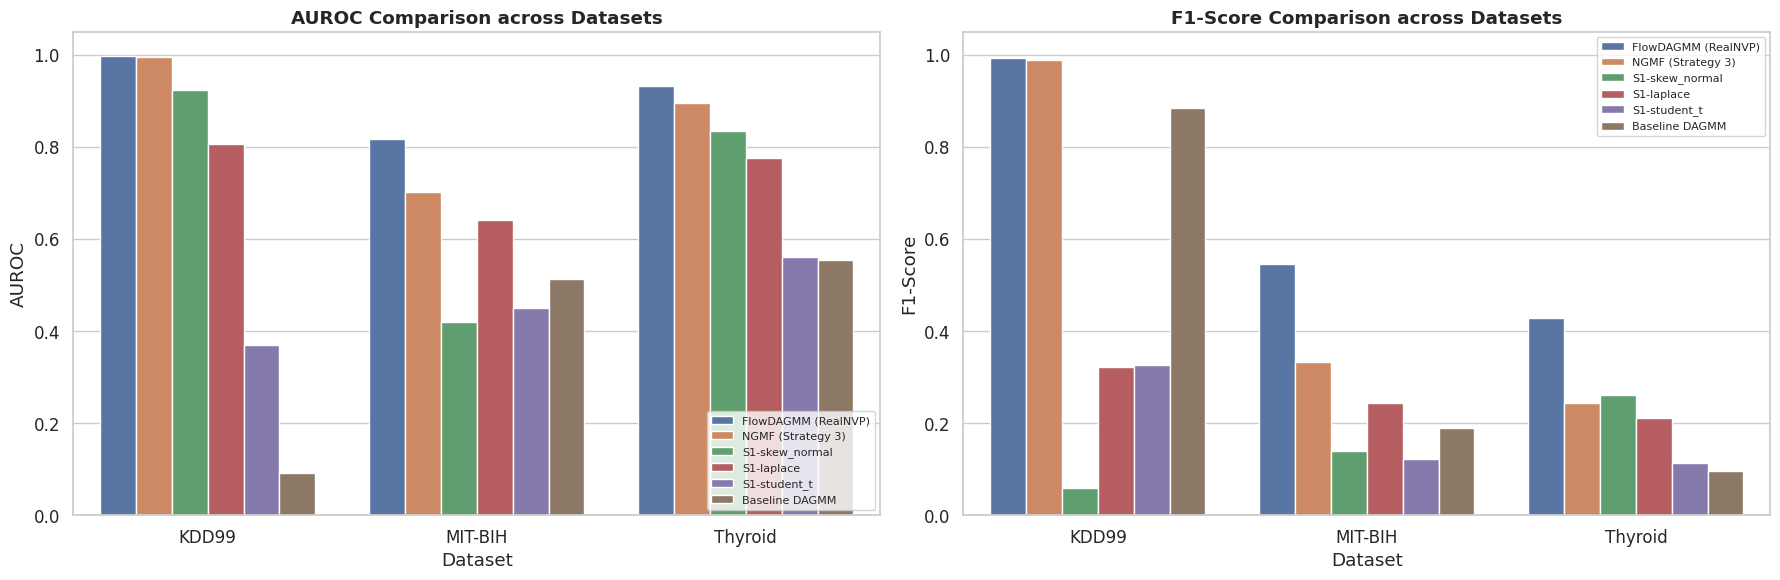

Saved strategy_comparison_bars.png


In [ ]:
sns.set_theme(style="whitegrid", font_scale=1.1)

# Filter to our strategy models only for a cleaner chart
strategy_models = ["Baseline DAGMM", "S1-student_t", "S1-laplace", "S1-skew_normal",
                   "FlowDAGMM (RealNVP)", "NGMF (Strategy 3)"]
df_strats = df_results[df_results["model"].isin(strategy_models)].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=df_strats, x="dataset", y="auroc", hue="model", ax=axes[0])
axes[0].set_title("AUROC Comparison across Datasets", fontweight='bold')
axes[0].set_ylabel("AUROC")
axes[0].set_xlabel("Dataset")
axes[0].legend(loc='lower right', fontsize=8)
axes[0].set_ylim(0, 1.05)

sns.barplot(data=df_strats, x="dataset", y="f1", hue="model", ax=axes[1])
axes[1].set_title("F1-Score Comparison across Datasets", fontweight='bold')
axes[1].set_ylabel("F1-Score")
axes[1].set_xlabel("Dataset")
axes[1].legend(loc='upper right', fontsize=8)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("results/strategy_comparison_bars.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved strategy_comparison_bars.png")


### 10.2 Full Comparison (All Models)

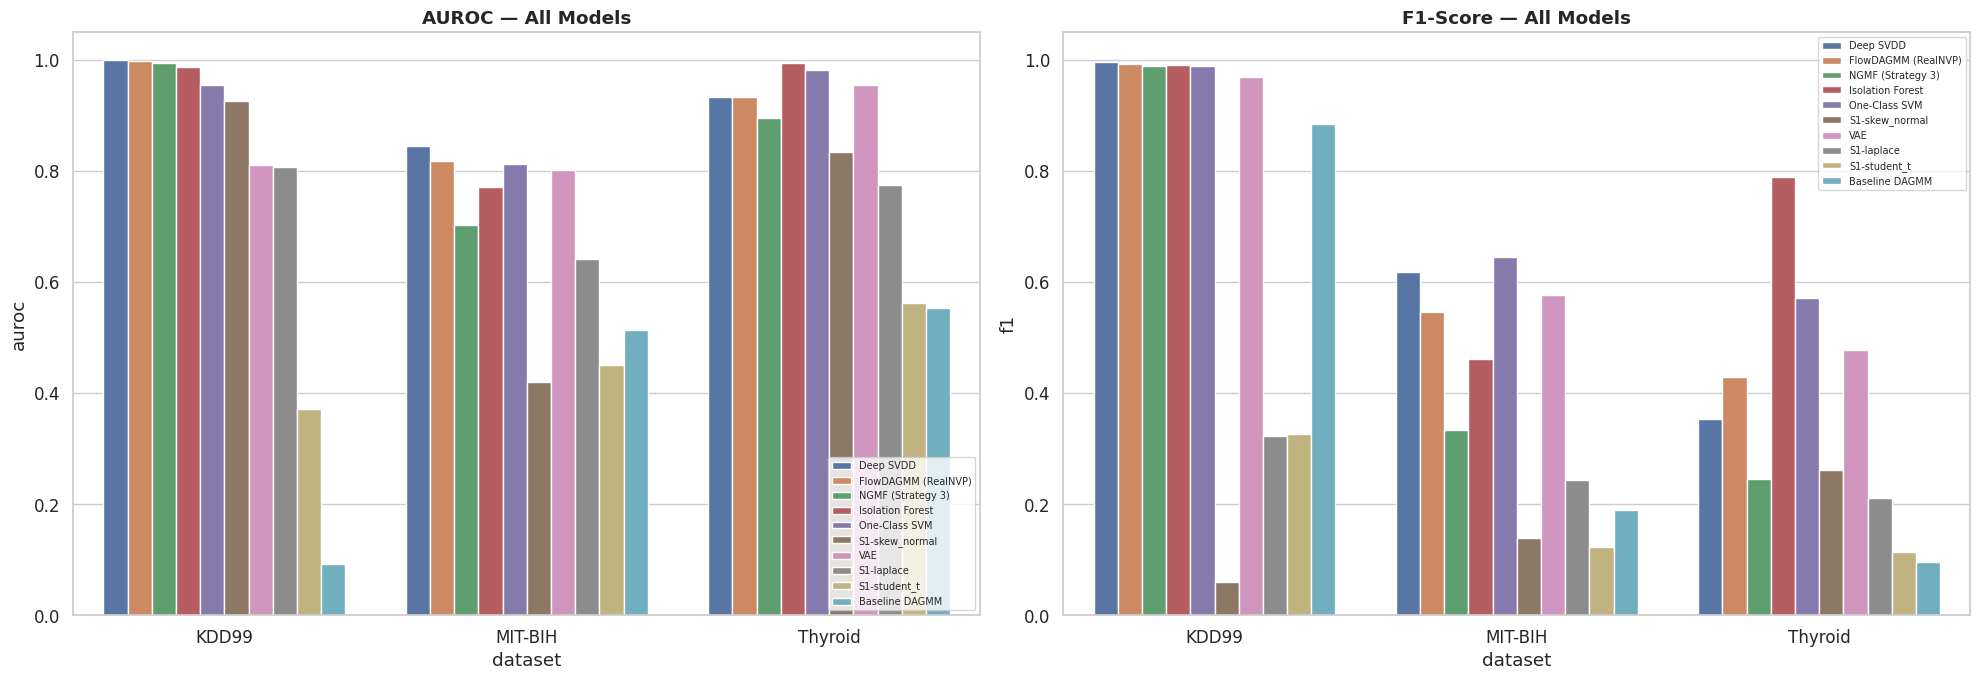

Saved all_models_comparison_bars.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sns.barplot(data=df_results, x="dataset", y="auroc", hue="model", ax=axes[0])
axes[0].set_title("AUROC — All Models", fontweight='bold')
axes[0].legend(loc='lower right', fontsize=7)
axes[0].set_ylim(0, 1.05)

sns.barplot(data=df_results, x="dataset", y="f1", hue="model", ax=axes[1])
axes[1].set_title("F1-Score — All Models", fontweight='bold')
axes[1].legend(loc='upper right', fontsize=7)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("results/all_models_comparison_bars.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved all_models_comparison_bars.png")


### 10.3 KDE Plots — Anomaly Score Distributions

KDE overlays of normal vs anomaly score distributions to show how well each
strategy separates the two classes.


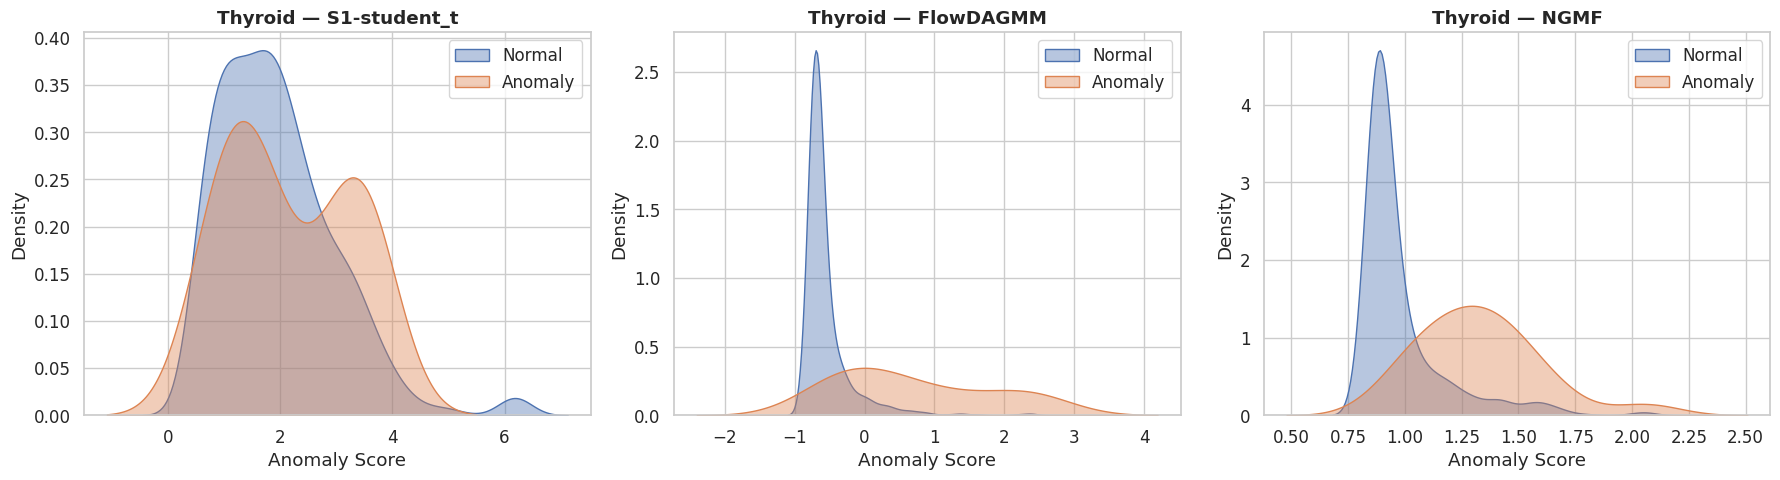

Saved kde_thyroid.png


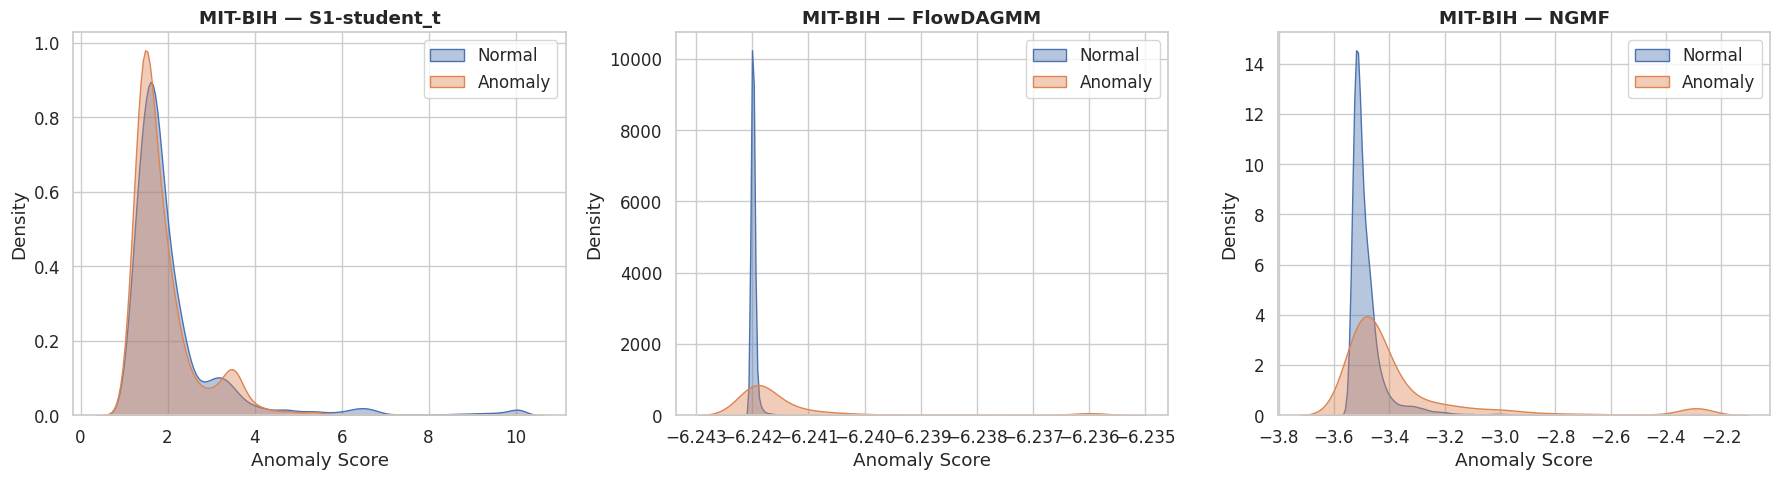

Saved kde_mit-bih.png


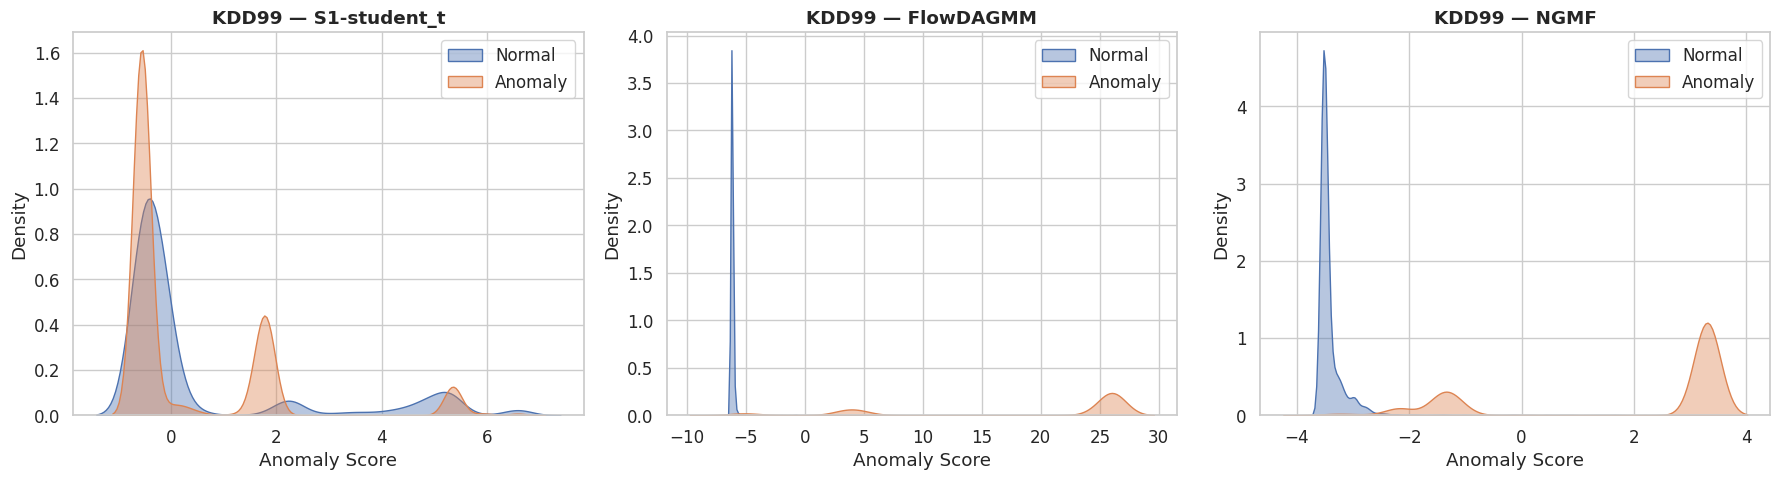

Saved kde_kdd99.png


In [ ]:
for ds_name, strats in plot_data.items():
    if not strats:
        continue

    n = len(strats)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    if n == 1:
        axes = [axes]

    for idx, (sname, sdata) in enumerate(strats.items()):
        scores = sdata["scores"]
        labels = sdata["labels"]

        # Clip extreme outliers for cleaner KDE
        q99 = np.percentile(scores, 99.5)
        scores_clipped = np.clip(scores, None, q99)

        sns.kdeplot(scores_clipped[labels==0], ax=axes[idx], label="Normal",
                    fill=True, alpha=0.4, common_norm=False)
        sns.kdeplot(scores_clipped[labels==1], ax=axes[idx], label="Anomaly",
                    fill=True, alpha=0.4, common_norm=False)
        axes[idx].set_title(f"{ds_name} — {sname}", fontweight='bold')
        axes[idx].set_xlabel("Anomaly Score")
        axes[idx].legend()

    plt.tight_layout()
    plt.savefig(f"results/kde_{ds_name.lower()}.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved kde_{ds_name.lower()}.png")


### 10.4 t-SNE Latent Space Visualization

t-SNE projection of the **latent z vectors** (the autoencoder's learned
representation) to visualize how each strategy separates normal samples from
anomalies in the learned latent space.


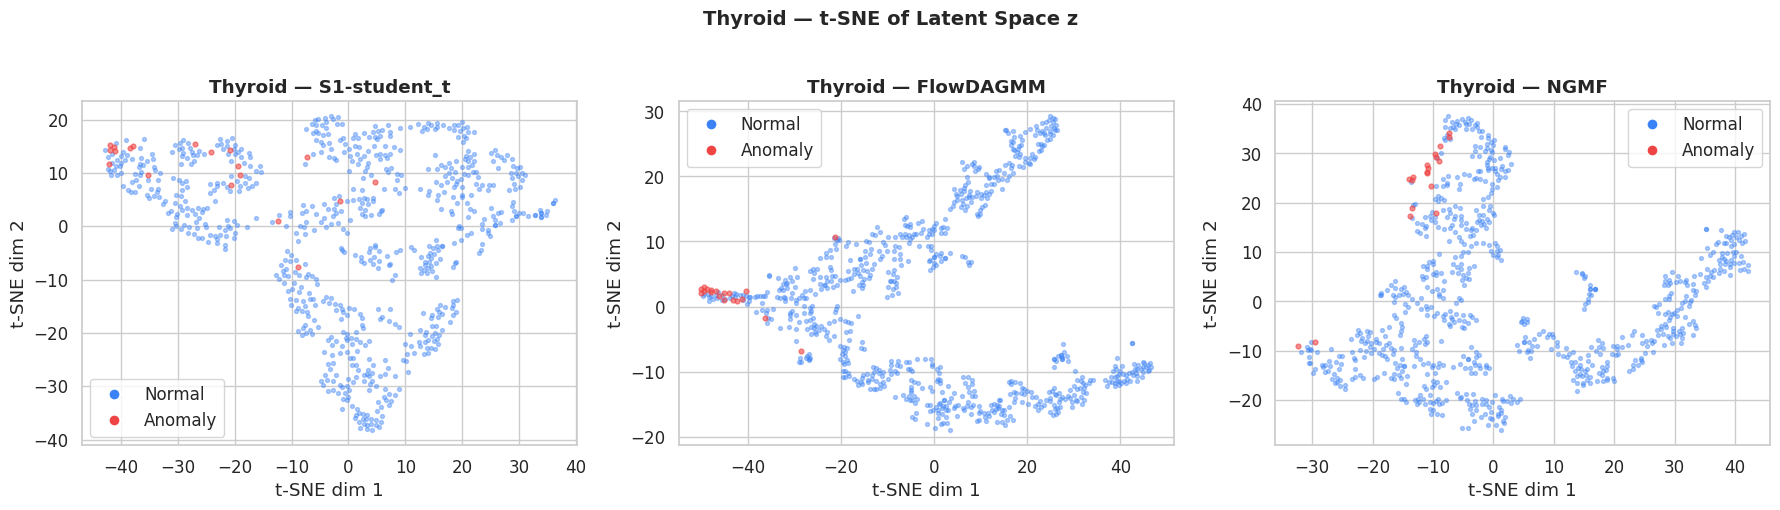

Saved tsne_thyroid.png


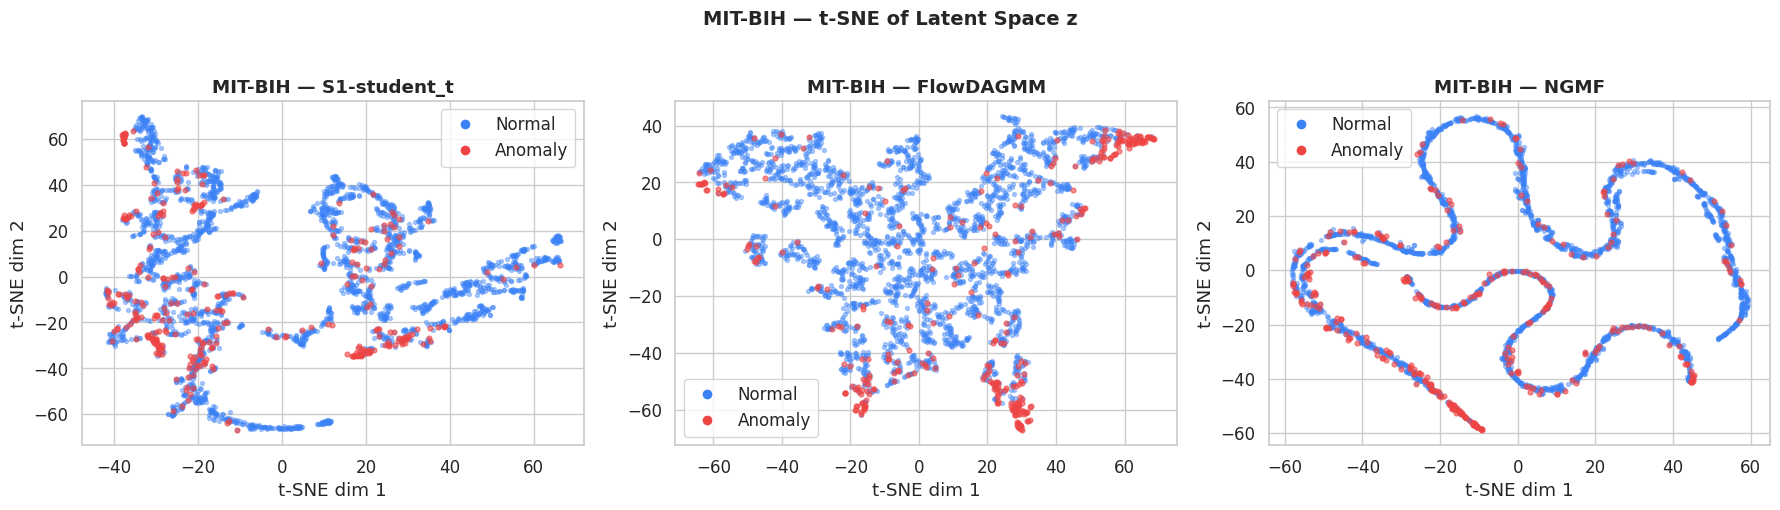

Saved tsne_mit-bih.png


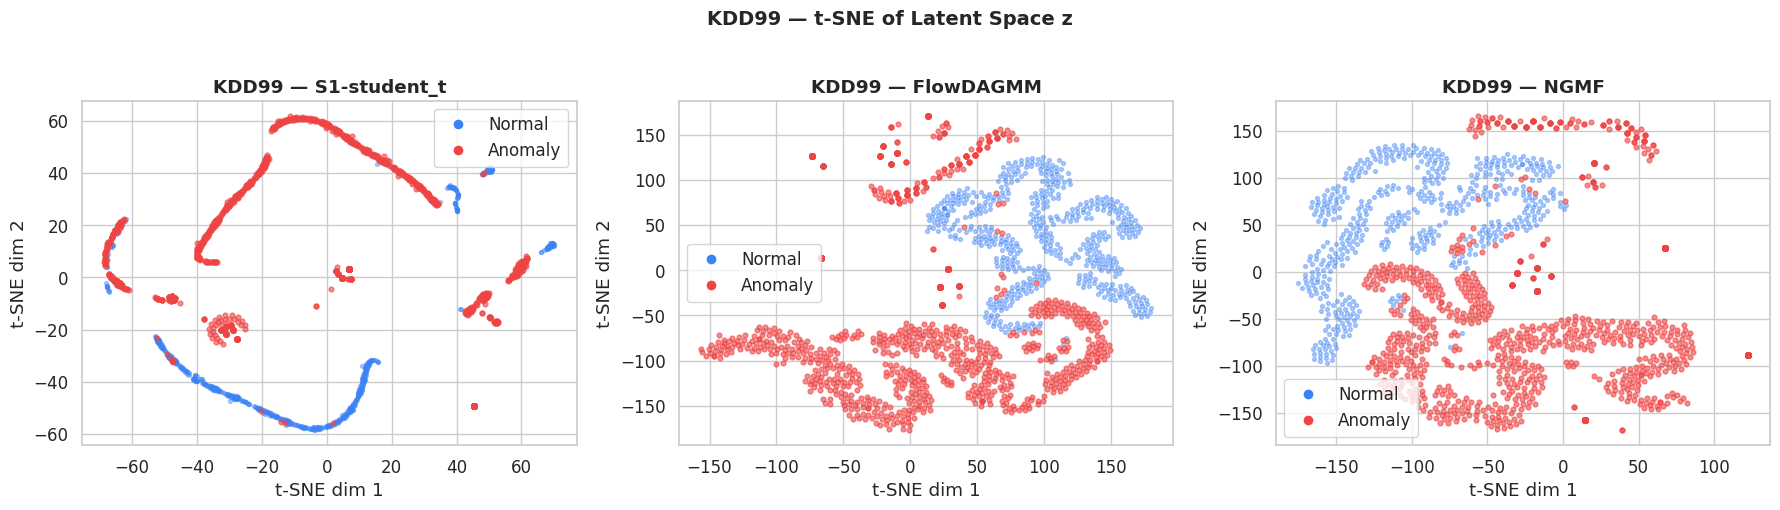

Saved tsne_kdd99.png


In [ ]:
from matplotlib.lines import Line2D

for ds_name, strats in plot_data.items():
    if not strats:
        continue

    # Only plot strategies that have embeddings
    strategies_to_plot = [s for s in strats.keys() if "embeds" in strats[s]]
    if not strategies_to_plot:
        continue

    n = len(strategies_to_plot)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    if n == 1:
        axes = [axes]

    for idx, sname in enumerate(strategies_to_plot):
        sdata = strats[sname]
        embeds = sdata["embeds"]    # actual latent z vectors (N, d)
        labels = sdata["labels"]

        # Subsample for t-SNE speed
        n_samples = min(3000, len(labels))
        rng = np.random.default_rng(42)
        sample_idx = rng.choice(len(labels), n_samples, replace=False)

        embeds_sub = embeds[sample_idx]   # (n_samples, d) — multi-dimensional
        labels_sub = labels[sample_idx]

        if embeds_sub.shape[0] > 5:
            # Clean any NaN/Inf values
            embeds_sub = np.nan_to_num(embeds_sub, nan=0.0, posinf=1e6, neginf=-1e6)

            tsne = TSNE(n_components=2, perplexity=min(30, n_samples-1),
                        random_state=42, max_iter=1000)
            embedded = tsne.fit_transform(embeds_sub)

            # Scatter with distinct colours for normal vs anomaly
            normal_mask = labels_sub == 0
            anomaly_mask = labels_sub == 1

            axes[idx].scatter(embedded[normal_mask, 0], embedded[normal_mask, 1],
                            c='#3B82F6', alpha=0.4, s=8, label='Normal')
            axes[idx].scatter(embedded[anomaly_mask, 0], embedded[anomaly_mask, 1],
                            c='#EF4444', alpha=0.6, s=12, label='Anomaly')
            axes[idx].set_title(f"{ds_name} — {sname}", fontweight='bold')
            axes[idx].set_xlabel("t-SNE dim 1")
            axes[idx].set_ylabel("t-SNE dim 2")

            legend_elements = [
                Line2D([0], [0], marker='o', color='w', markerfacecolor='#3B82F6',
                       markersize=8, label='Normal'),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='#EF4444',
                       markersize=8, label='Anomaly'),
            ]
            axes[idx].legend(handles=legend_elements, loc='best')

    fig.suptitle(f"{ds_name} — t-SNE of Latent Space z", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f"results/tsne_{ds_name.lower()}.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved tsne_{ds_name.lower()}.png")


---
## Summary

All results are saved to **`final_results.csv`** and plot images are saved alongside the notebook.

| File | Contents |
|------|----------|
| `final_results.csv` | Full results table (all strategies × all datasets) |
| `strategy_comparison_bars.png` | AUROC/F1 bar chart for strategies only |
| `all_models_comparison_bars.png` | AUROC/F1 bar chart for all models |
| `kde_*.png` | KDE anomaly score distributions per dataset |
| `tsne_*.png` | t-SNE latent space visualizations per dataset |
